# Una red biohíbrida que se mueve y captura nanoplásticos

**El nanoplástico es invisible: pasa los filtros, llega al agua que bebes, y se cuela en tu sangre.** Un equipo del ETH Zürich construyó una red diminuta hecha de proteína de huevo y partículas de hierro, que se mueve con un imán y atrapa el 99% de los nanoplásticos. Y se reusa 100 veces.

[![Abrir en Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Ciencia-a-Mordiscos/lab/blob/main/papers/2026-04-23-nanonets-amiloide-nanoplasticos/notebook.ipynb)

📄 **Paper:** Nature Water · DOI: [10.1038/s44221-026-00620-1](https://doi.org/10.1038/s44221-026-00620-1)
🎬 **Video:** Pendiente

## ¿Qué hicieron y por qué importa?

Los **nanoplásticos** (pedazos menores a 1.000 nm) escapan a casi cualquier filtro de agua. No los vemos, pero ya están en sangre, placenta y cerebro humanos. Los métodos actuales (filtración, coagulación, adsorbentes pasivos) los dejan pasar a partir de cierto tamaño, o se saturan rápido.

El equipo construyó una solución biohíbrida: **LAF-IONPs**, redes de fibrillas amiloides de **lisozima** (la proteína de la clara del huevo) decoradas en el momento con **nanopartículas de óxido de hierro**. La fibrilla atrapa el plástico por afinidad química; el hierro hace que toda la red responda a un imán. Un campo magnético alterno la sacude, multiplica los choques con el plástico, y el conjunto se recoge magnéticamente para reusar.

Veamos los datos de eficiencia del paper, qué tan duradero es el material, y si funciona dentro de un ratón vivo.

In [1]:
# ══════════════════════════════════════════════════════════════
# Configuración — modifica estos valores para explorar
# ══════════════════════════════════════════════════════════════
EFICIENCIA_OBJETIVO = 95.0           # umbral típico de filtración avanzada (%)
COLOR_DATOS = '#2563EB'              # azul CaM
COLOR_ALERTA = '#DC2626'             # rojo (estático / sin tratamiento)
COLOR_REFERENCIA = '#D97706'         # ámbar (umbrales)
COLOR_SECUNDARIO = '#059669'         # esmeralda (datos comparativos)
FUENTE = 'Fuente: Fan et al., Nature Water (2026) | DOI: 10.1038/s44221-026-00620-1'

# ══════════════════════════════════════════════════════════════
# Imports + carga de datos
# ══════════════════════════════════════════════════════════════
import os, urllib.request
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Estilo CaM (local en repo, Colab descarga del GitHub raw)
style_file = '../../cam.mplstyle'
if not os.path.exists(style_file):
    style_file = '/tmp/cam.mplstyle'
    if not os.path.exists(style_file):
        urllib.request.urlretrieve(
            'https://raw.githubusercontent.com/Ciencia-a-Mordiscos/lab/main/cam.mplstyle',
            style_file)
plt.style.use(style_file)

# Asegurar carpeta de figuras
os.makedirs('figuras', exist_ok=True)

# Carga de los 6 CSVs derivados del Source Data del paper
df_conc   = pd.read_csv('datos/eficiencia_vs_concentracion.csv')
df_tam    = pd.read_csv('datos/eficiencia_vs_tamano.csv')
df_movim  = pd.read_csv('datos/estatico_vs_dinamico.csv')
df_ciclos = pd.read_csv('datos/ciclos_100.csv')
df_vivo   = pd.read_csv('datos/in_vivo_fluorescencia.csv')
df_aguas  = pd.read_csv('datos/aguas_reales_ciclos.csv')

print(f'Concentración: {len(df_conc)} medidas, {df_conc.concentracion_mg_L.nunique()} niveles (10–1.000 mg/L)')
print(f'Tamaño:        {len(df_tam)} medidas, {df_tam.tamano_nm.nunique()} tamaños de PS (30/100/200 nm)')
print(f'Movimiento:    {len(df_movim)} medidas, n=3 por condición (estático vs dinámico)')
print(f'Ciclado:       {len(df_ciclos)} medidas, 10 puntos × 3 réplicas (cada 10 ciclos hasta 100)')
print(f'In vivo:       {len(df_vivo)} ratones, 3 grupos × 3 individuos (Control / PS / PS+LAF-IONPs)')
print(f'Aguas reales:  {len(df_aguas)} medidas en 4 tipos de agua durante 5 ciclos')

Concentración: 21 medidas, 7 niveles (10–1.000 mg/L)
Tamaño:        9 medidas, 3 tamaños de PS (30/100/200 nm)
Movimiento:    6 medidas, n=3 por condición (estático vs dinámico)
Ciclado:       30 medidas, 10 puntos × 3 réplicas (cada 10 ciclos hasta 100)
In vivo:       9 ratones, 3 grupos × 3 individuos (Control / PS / PS+LAF-IONPs)
Aguas reales:  60 medidas en 4 tipos de agua durante 5 ciclos


## Aquí está.

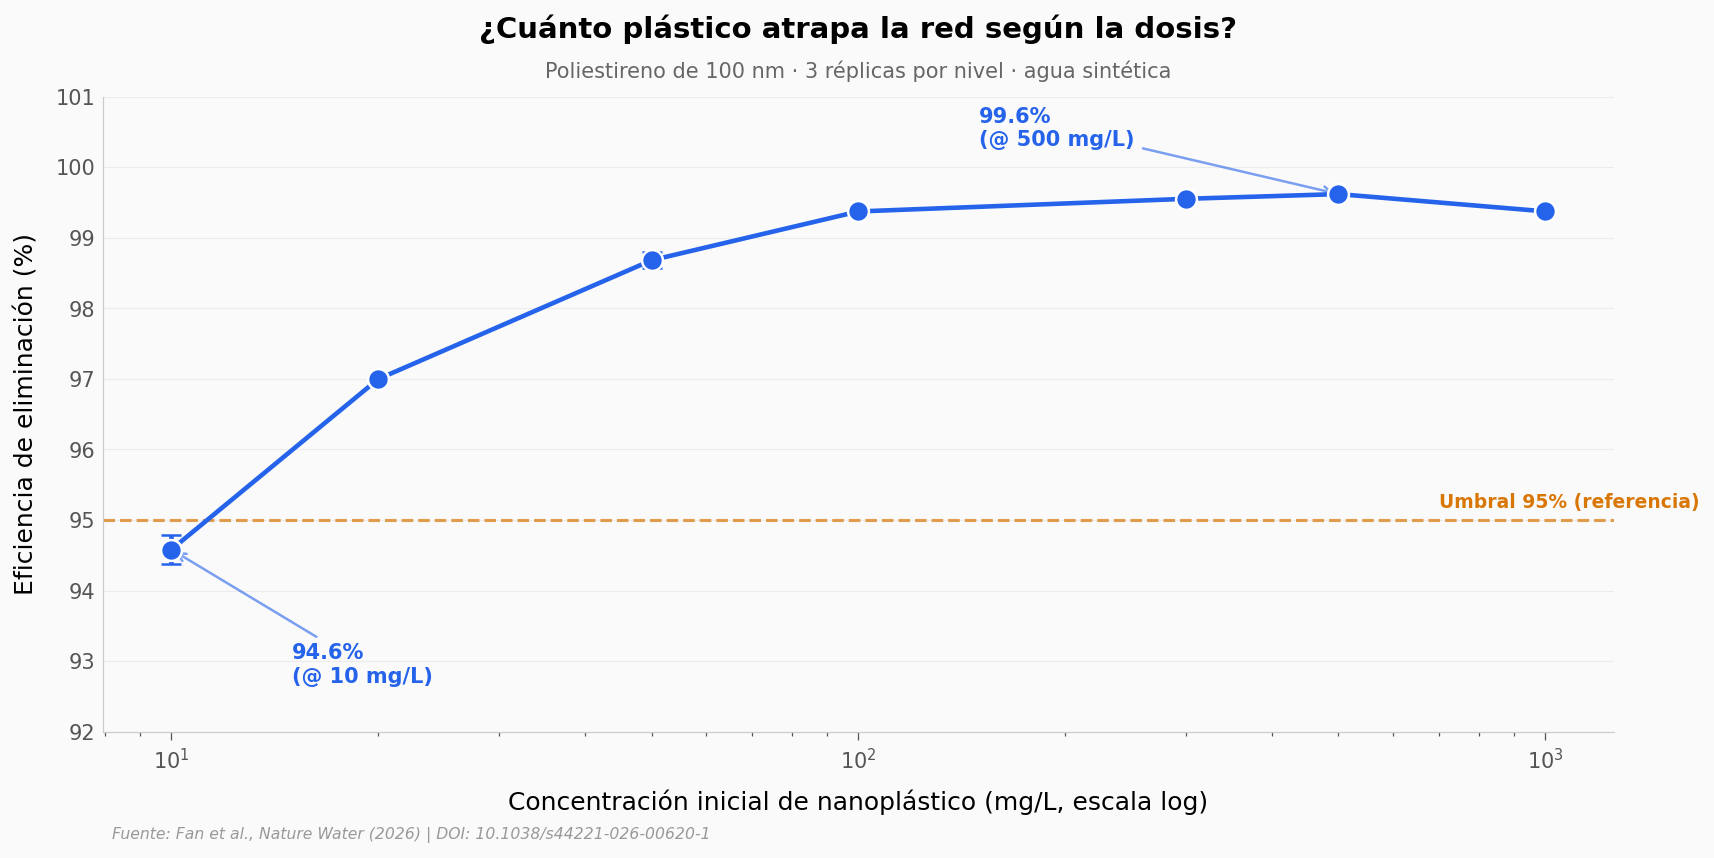

In [2]:
# Hero chart: eficiencia de eliminación según cuánto plástico haya
fig, ax = plt.subplots(figsize=(13, 5.5))

# Promedio + desviación por concentración
res = df_conc.groupby('concentracion_mg_L')['eficiencia_pct'].agg(['mean', 'std']).reset_index()
ax.errorbar(res['concentracion_mg_L'], res['mean'], yerr=res['std'],
            fmt='o-', color=COLOR_DATOS, markersize=10, linewidth=2.2,
            capsize=5, capthick=1.5, markeredgecolor='white', markeredgewidth=1.2,
            zorder=5, label='LAF-IONPs')

# Línea de referencia: 95% (filtración avanzada típica)
ax.axhline(y=EFICIENCIA_OBJETIVO, color=COLOR_REFERENCIA, linewidth=1.5,
           linestyle='--', alpha=0.7, zorder=2)
ax.text(700, EFICIENCIA_OBJETIVO + 0.18, 'Umbral 95% (referencia)',
        fontsize=9, color=COLOR_REFERENCIA, fontweight='bold')

ax.set_xscale('log')
ax.set_xlabel('Concentración inicial de nanoplástico (mg/L, escala log)')
ax.set_ylabel('Eficiencia de eliminación (%)')
ax.set_title('¿Cuánto plástico atrapa la red según la dosis?',
             fontsize=14, fontweight='bold', pad=28)
ax.text(0.5, 1.03, 'Poliestireno de 100 nm · 3 réplicas por nivel · agua sintética',
        transform=ax.transAxes, fontsize=10, color='#666666', ha='center')
ax.set_ylim(92, 101)

# Anotaciones para el peor y el mejor caso
peor = res.loc[res['mean'].idxmin()]
mejor = res.loc[res['mean'].idxmax()]
ax.annotate(f'{peor["mean"]:.1f}%\n(@ {int(peor.concentracion_mg_L)} mg/L)',
            xy=(peor.concentracion_mg_L, peor['mean']),
            xytext=(15, 92.7), fontsize=10, fontweight='bold', color=COLOR_DATOS,
            arrowprops=dict(arrowstyle='->', color=COLOR_DATOS, lw=1.2, alpha=0.6))
ax.annotate(f'{mejor["mean"]:.1f}%\n(@ {int(mejor.concentracion_mg_L)} mg/L)',
            xy=(mejor.concentracion_mg_L, mejor['mean']),
            xytext=(150, 100.3), fontsize=10, fontweight='bold', color=COLOR_DATOS,
            arrowprops=dict(arrowstyle='->', color=COLOR_DATOS, lw=1.2, alpha=0.6))

fig.text(0.13, -0.02, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.savefig('figuras/01_eficiencia_concentracion.png', dpi=200, bbox_inches='tight')
plt.show()

La eficiencia parte en **94,6%** con muy poco plástico (10 mg/L) y trepa hasta **99,6%** cuando hay más material en el agua. Es contraintuitivo: cuanto más sucia el agua, mejor funciona la red. La razón está en el mecanismo — más plástico significa más choques con las fibrillas, así que el material aprovecha mejor su superficie.

Por encima de 50 mg/L la curva se aplana cerca del 99%. La red parece tener un techo de eficiencia que no depende de la dosis: una vez activado el régimen, la captura es casi total.

## ¿Y si cambia el tamaño del plástico?

Los nanoplásticos del mundo real no vienen en una sola talla. Las botellas degradadas producen partículas de cientos de nanómetros; los textiles y cosméticos sueltan piezas más pequeñas. El abstract afirma cobertura de **30 a 1.000 nm**; el Source Data del paper trae mediciones en tres puntos clave: 30, 100 y 200 nm.

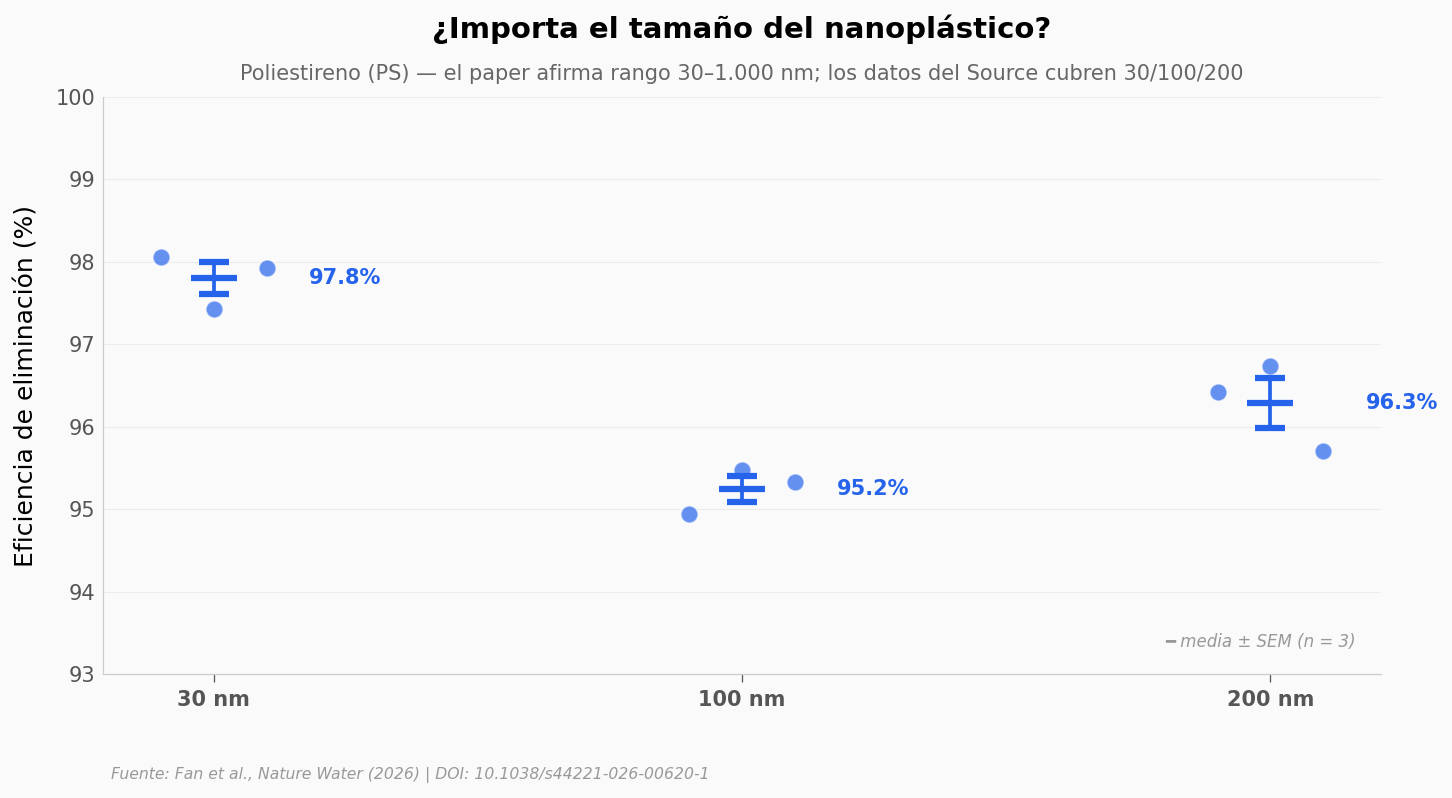

Diferencia 30 → 100 nm: 2.56 pp · Cohen d = 8.3


In [3]:
# Eficiencia por tamaño de PS — n=3 por tamaño
fig, ax = plt.subplots(figsize=(11, 5))

np.random.seed(42)
tamanos = sorted(df_tam.tamano_nm.unique())
positions = list(range(len(tamanos)))

for i, t in enumerate(tamanos):
    vals = df_tam[df_tam.tamano_nm == t].eficiencia_pct.values
    n = len(vals)
    x_strip = np.linspace(positions[i] - 0.10, positions[i] + 0.10, n)
    np.random.shuffle(x_strip)
    ax.scatter(x_strip, vals, color=COLOR_DATOS, s=70, alpha=0.7,
               edgecolors='white', linewidths=0.8, zorder=5)
    mean = vals.mean()
    sem = vals.std(ddof=1) / np.sqrt(n)
    ax.errorbar(positions[i], mean, yerr=sem, fmt='_', color=COLOR_DATOS,
                markersize=22, markeredgewidth=3,
                capsize=7, capthick=1.6, zorder=6)
    ax.text(positions[i] + 0.18, mean, f'{mean:.1f}%',
            fontsize=10, fontweight='bold', color=COLOR_DATOS,
            va='center', ha='left')

ax.set_xticks(positions)
ax.set_xticklabels([f'{t} nm' for t in tamanos], fontsize=10, fontweight='bold')
ax.set_ylabel('Eficiencia de eliminación (%)')
ax.set_title('¿Importa el tamaño del nanoplástico?',
             fontsize=14, fontweight='bold', pad=28)
ax.text(0.5, 1.03, 'Poliestireno (PS) — el paper afirma rango 30–1.000 nm; los datos del Source cubren 30/100/200',
        transform=ax.transAxes, fontsize=10, color='#666666', ha='center')
ax.set_ylim(93, 100)
ax.text(0.98, 0.04, '━ media ± SEM (n = 3)', transform=ax.transAxes,
        fontsize=8, color='#999999', ha='right', va='bottom', style='italic')

fig.text(0.13, -0.03, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.savefig('figuras/02_eficiencia_tamano.png', dpi=200, bbox_inches='tight')
plt.show()

# Cohen d entre los extremos como referencia descriptiva
v30  = df_tam[df_tam.tamano_nm==30].eficiencia_pct.values
v100 = df_tam[df_tam.tamano_nm==100].eficiencia_pct.values
pooled = np.sqrt((v30.var(ddof=1)+v100.var(ddof=1))/2)
print(f'Diferencia 30 → 100 nm: {v30.mean()-v100.mean():.2f} pp · Cohen d = {(v30.mean()-v100.mean())/pooled:.1f}')

## El truco mecánico: la red no atrapa, **caza**

Aquí está la pieza más interesante del paper. Si dejas la red flotando con el plástico (régimen **estático**), captura una fracción modesta. Si encierras todo en un campo magnético alterno (régimen **dinámico**), la red se sacude y atraviesa el agua. Compara los dos modos.

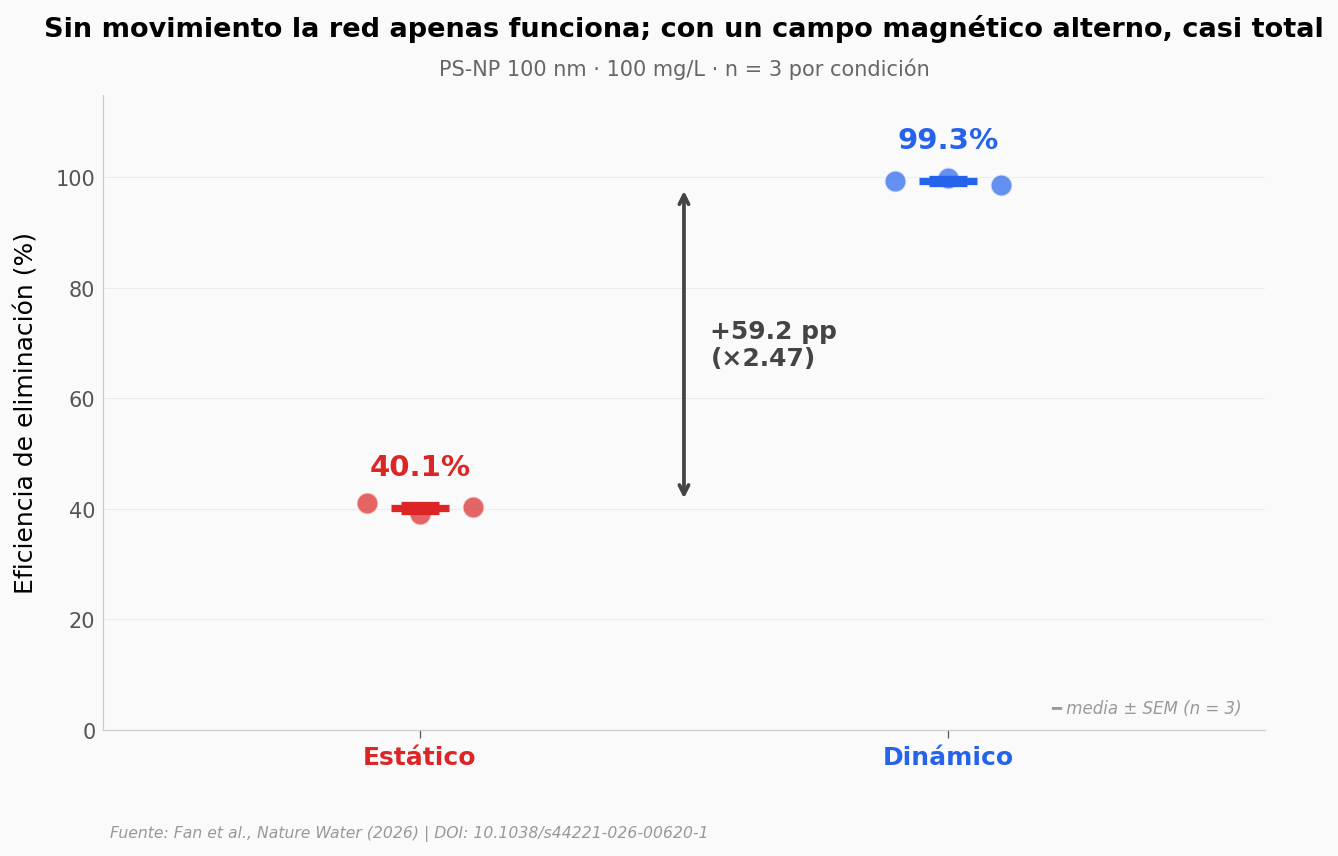

Diferencia: 59.17 pp · fold ×2.47 · Cohen d = 71.5
Nota: con n = 3 por grupo, el p mínimo posible para Mann–Whitney es 0,1 — 
reportamos la magnitud (Cohen d ≈ 71, enorme) en lugar del p-valor sub-poderado.


In [4]:
fig, ax = plt.subplots(figsize=(10, 5.5))

np.random.seed(42)
condiciones = ['Estático', 'Dinámico']
colores = [COLOR_ALERTA, COLOR_DATOS]
positions = [0, 1]

for i, (cond, col) in enumerate(zip(condiciones, colores)):
    vals = df_movim[df_movim.condicion == cond].eficiencia_pct.values
    n = len(vals)
    x_strip = np.linspace(positions[i] - 0.10, positions[i] + 0.10, n)
    np.random.shuffle(x_strip)
    ax.scatter(x_strip, vals, color=col, s=110, alpha=0.7,
               edgecolors='white', linewidths=1.0, zorder=5)
    mean = vals.mean()
    sem = vals.std(ddof=1) / np.sqrt(n)
    ax.errorbar(positions[i], mean, yerr=sem, fmt='_', color=col,
                markersize=28, markeredgewidth=3.5,
                capsize=9, capthick=1.8, zorder=6)
    ax.text(positions[i], mean + 6, f'{mean:.1f}%',
            fontsize=14, fontweight='bold', color=col, ha='center')

# Flecha bidireccional: la diferencia
m_e = df_movim[df_movim.condicion=='Estático'].eficiencia_pct.mean()
m_d = df_movim[df_movim.condicion=='Dinámico'].eficiencia_pct.mean()
ax.annotate('', xy=(0.5, m_d - 1), xytext=(0.5, m_e + 1),
            arrowprops=dict(arrowstyle='<->', color='#444444', lw=1.8))
ax.text(0.55, (m_e + m_d)/2, f'+{m_d-m_e:.1f} pp\n(×{m_d/m_e:.2f})',
        fontsize=12, fontweight='bold', color='#444444', va='center')

ax.set_xticks(positions)
ax.set_xticklabels(condiciones, fontsize=12, fontweight='bold')
for tick, col in zip(ax.get_xticklabels(), colores):
    tick.set_color(col)
ax.set_ylabel('Eficiencia de eliminación (%)')
ax.set_xlim(-0.6, 1.6)
ax.set_ylim(0, 115)
ax.set_title('Sin movimiento la red apenas funciona; con un campo magnético alterno, casi total',
             fontsize=13, fontweight='bold', pad=28)
ax.text(0.5, 1.03, 'PS-NP 100 nm · 100 mg/L · n = 3 por condición',
        transform=ax.transAxes, fontsize=10, color='#666666', ha='center')
ax.text(0.98, 0.02, '━ media ± SEM (n = 3)', transform=ax.transAxes,
        fontsize=8, color='#999999', ha='right', va='bottom', style='italic')

fig.text(0.13, -0.02, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.savefig('figuras/03_estatico_dinamico.png', dpi=200, bbox_inches='tight')
plt.show()

# Effect size descriptivo (n=3 por grupo)
e = df_movim[df_movim.condicion=='Estático'].eficiencia_pct.values
d = df_movim[df_movim.condicion=='Dinámico'].eficiencia_pct.values
pooled = np.sqrt((e.var(ddof=1)+d.var(ddof=1))/2)
print(f'Diferencia: {d.mean()-e.mean():.2f} pp · fold ×{d.mean()/e.mean():.2f} · Cohen d = {(d.mean()-e.mean())/pooled:.1f}')
print('Nota: con n = 3 por grupo, el p mínimo posible para Mann–Whitney es 0,1 — ')
print('reportamos la magnitud (Cohen d ≈ 71, enorme) en lugar del p-valor sub-poderado.')

## ¿Funciona dentro de un cuerpo vivo?

Eliminar plástico de un vaso de agua es una cosa; demostrar que el material reduce el plástico que ya está dentro de un organismo es otra muy distinta. El equipo lo probó en ratones C57BL/6 expuestos a poliestireno marcado con fluorescencia, midiendo cuánto plástico se acumulaba en el tejido tras administrar (o no) las nanonets.

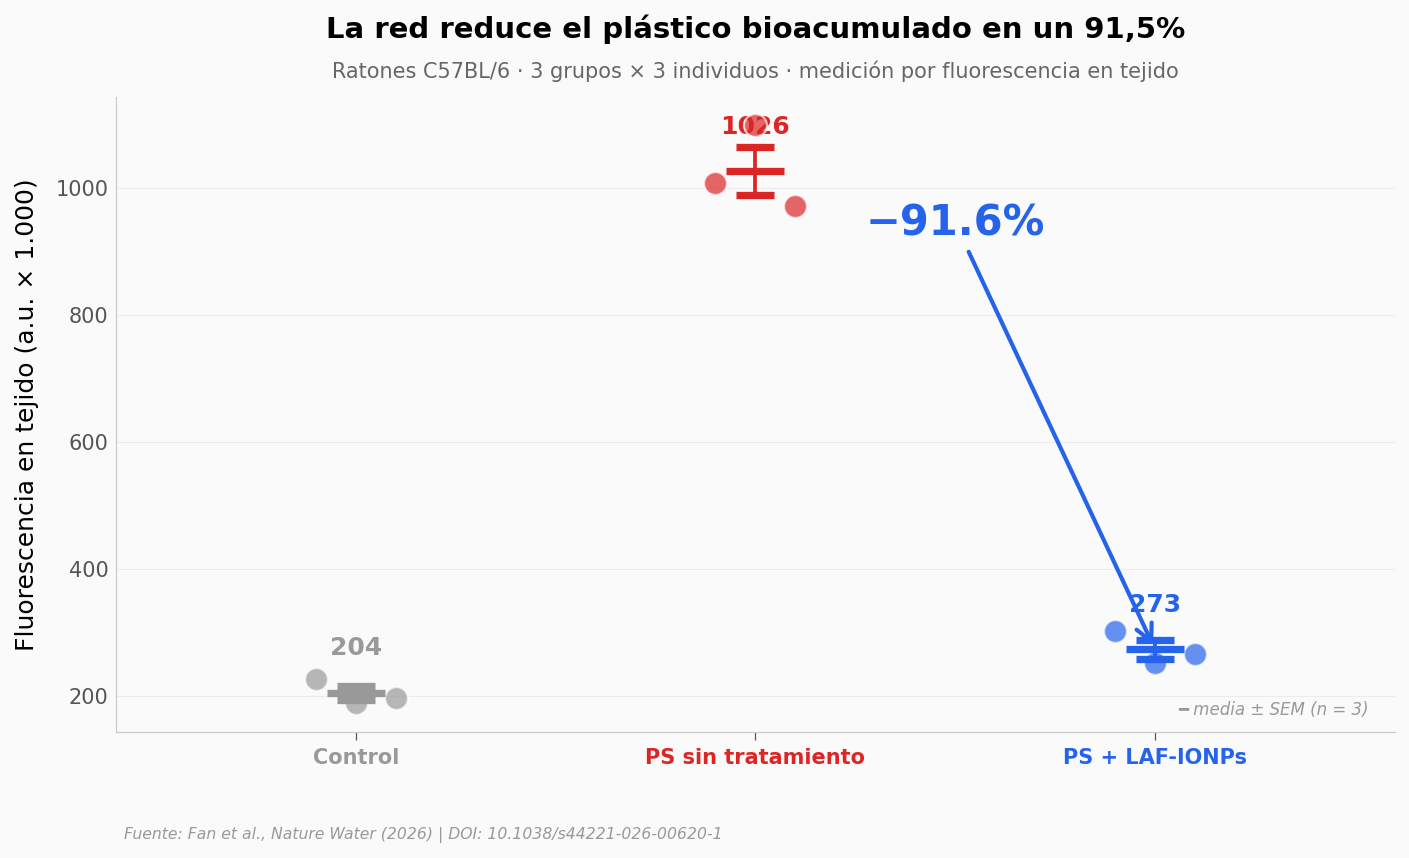

Control: 204122 a.u.
PS sin tratamiento: 1026332 a.u.
PS + LAF-IONPs: 273433 a.u.
Reducción: (PS − PS+IONPs) / (PS − Control) × 100 = 91.6%
Coincide con el 91,5% reportado en el abstract (diferencia <0,1 pp por redondeo).


In [5]:
fig, ax = plt.subplots(figsize=(11, 5.5))

np.random.seed(42)
grupos = ['Control', 'PS sin tratamiento', 'PS + LAF-IONPs']
colores = ['#999999', COLOR_ALERTA, COLOR_DATOS]
positions = [0, 1, 2]

for i, (g, col) in enumerate(zip(grupos, colores)):
    vals = df_vivo[df_vivo.grupo == g].fluorescencia_au.values / 1000  # a miles
    n = len(vals)
    x_strip = np.linspace(positions[i] - 0.10, positions[i] + 0.10, n)
    np.random.shuffle(x_strip)
    ax.scatter(x_strip, vals, color=col, s=120, alpha=0.7,
               edgecolors='white', linewidths=1.0, zorder=5)
    mean = vals.mean()
    sem = vals.std(ddof=1) / np.sqrt(n)
    ax.errorbar(positions[i], mean, yerr=sem, fmt='_', color=col,
                markersize=28, markeredgewidth=3.5,
                capsize=9, capthick=1.8, zorder=6)
    ax.text(positions[i], mean + 60, f'{mean:.0f}',
            fontsize=12, fontweight='bold', color=col, ha='center')

# Calcular reducción
m = df_vivo.groupby('grupo').fluorescencia_au.mean()
red_pct = (m['PS sin tratamiento'] - m['PS + LAF-IONPs']) / (m['PS sin tratamiento'] - m['Control']) * 100
ax.annotate(f'−{red_pct:.1f}%',
            xy=(2, m['PS + LAF-IONPs']/1000), xytext=(1.5, m['PS sin tratamiento']/1000 - 100),
            fontsize=20, fontweight='bold', color=COLOR_DATOS,
            ha='center',
            arrowprops=dict(arrowstyle='->', color=COLOR_DATOS, lw=2))

ax.set_xticks(positions)
ax.set_xticklabels(grupos, fontsize=10, fontweight='bold')
for tick, col in zip(ax.get_xticklabels(), colores):
    tick.set_color(col)
ax.set_ylabel('Fluorescencia en tejido (a.u. × 1.000)')
ax.set_xlim(-0.6, 2.6)
ax.set_title('La red reduce el plástico bioacumulado en un 91,5%',
             fontsize=14, fontweight='bold', pad=28)
ax.text(0.5, 1.03, 'Ratones C57BL/6 · 3 grupos × 3 individuos · medición por fluorescencia en tejido',
        transform=ax.transAxes, fontsize=10, color='#666666', ha='center')
ax.text(0.98, 0.02, '━ media ± SEM (n = 3)', transform=ax.transAxes,
        fontsize=8, color='#999999', ha='right', va='bottom', style='italic')

fig.text(0.13, -0.02, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.savefig('figuras/04_in_vivo.png', dpi=200, bbox_inches='tight')
plt.show()

print(f'Control: {m["Control"]:.0f} a.u.')
print(f'PS sin tratamiento: {m["PS sin tratamiento"]:.0f} a.u.')
print(f'PS + LAF-IONPs: {m["PS + LAF-IONPs"]:.0f} a.u.')
print(f'Reducción: (PS − PS+IONPs) / (PS − Control) × 100 = {red_pct:.1f}%')
print('Coincide con el 91,5% reportado en el abstract (diferencia <0,1 pp por redondeo).')

## ¿Y aguanta el uso?

Un material que captura el 99% pero se gasta en tres usos no es solución. El paper sometió las nanonets a **100 ciclos de captura-recuperación-reutilización** con un campo magnético alterno. ¿Qué tanto se degrada la eficiencia?

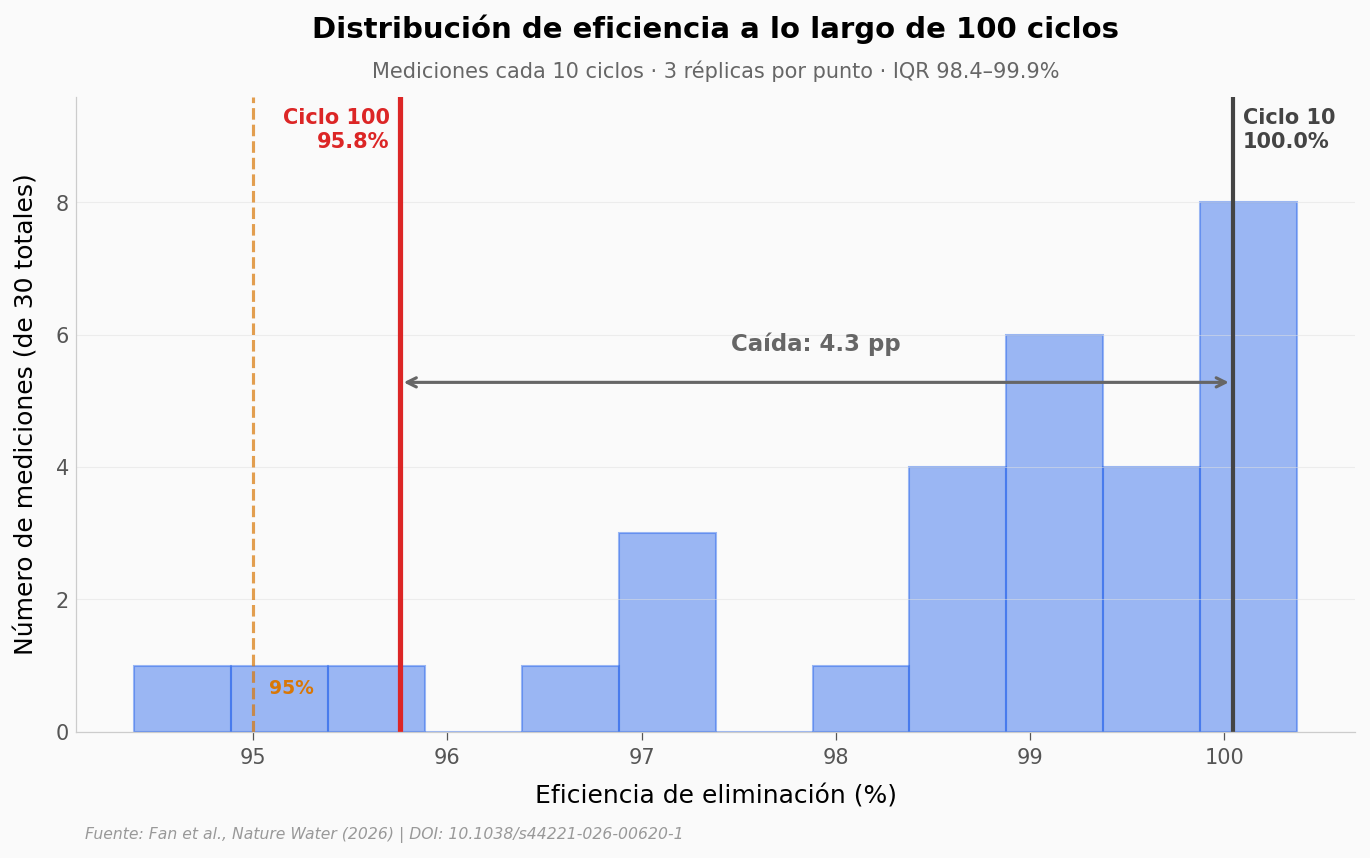

Eficiencia mediana sobre 100 ciclos: 99.29%
Rango global: 94.39–100.38%
Mediciones por debajo del 95%: 2/30


In [6]:
fig, ax = plt.subplots(figsize=(11, 5.5))

# Distribución de TODAS las eficiencias medidas durante los 100 ciclos
vals = df_ciclos.eficiencia_pct.values
n_total = len(vals)

n, bins, patches = ax.hist(vals, bins=12, color=COLOR_DATOS, alpha=0.45,
                           edgecolor=COLOR_DATOS, linewidth=1.0)
y_max = n.max() * 1.20
ax.set_ylim(0, y_max)

# Líneas de referencia: ciclo 1 vs ciclo 100
ciclo_10  = df_ciclos[df_ciclos.ciclo==10].eficiencia_pct.mean()
ciclo_100 = df_ciclos[df_ciclos.ciclo==100].eficiencia_pct.mean()
ax.axvline(x=ciclo_10, color='#444444', linewidth=2.0, linestyle='-')
ax.axvline(x=ciclo_100, color=COLOR_ALERTA, linewidth=2.5, linestyle='-')

ax.text(ciclo_10 + 0.05, y_max*0.92, f'Ciclo 10\n{ciclo_10:.1f}%',
        fontsize=10, fontweight='bold', color='#444444', ha='left')
ax.text(ciclo_100 - 0.05, y_max*0.92, f'Ciclo 100\n{ciclo_100:.1f}%',
        fontsize=10, fontweight='bold', color=COLOR_ALERTA, ha='right')

# Flecha: la caída
ax.annotate('', xy=(ciclo_100, y_max*0.55), xytext=(ciclo_10, y_max*0.55),
            arrowprops=dict(arrowstyle='<->', color='#666666', lw=1.5))
ax.text((ciclo_10+ciclo_100)/2, y_max*0.6, f'Caída: {ciclo_10-ciclo_100:.1f} pp',
        fontsize=11, fontweight='bold', color='#666666', ha='center')

# Umbral 95%
ax.axvline(x=EFICIENCIA_OBJETIVO, color=COLOR_REFERENCIA,
           linewidth=1.5, linestyle='--', alpha=0.7)
ax.text(EFICIENCIA_OBJETIVO + 0.08, y_max*0.06, '95%',
        fontsize=9, color=COLOR_REFERENCIA, fontweight='bold')

ax.set_xlabel('Eficiencia de eliminación (%)')
ax.set_ylabel(f'Número de mediciones (de {n_total} totales)')
ax.set_title('Distribución de eficiencia a lo largo de 100 ciclos',
             fontsize=14, fontweight='bold', pad=28)
ax.text(0.5, 1.03,
        f'Mediciones cada 10 ciclos · 3 réplicas por punto · IQR {np.percentile(vals,25):.1f}–{np.percentile(vals,75):.1f}%',
        transform=ax.transAxes, fontsize=10, color='#666666', ha='center')

fig.text(0.13, -0.02, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.savefig('figuras/05_ciclos_distribucion.png', dpi=200, bbox_inches='tight')
plt.show()

print(f'Eficiencia mediana sobre 100 ciclos: {np.median(vals):.2f}%')
print(f'Rango global: {vals.min():.2f}–{vals.max():.2f}%')
print(f'Mediciones por debajo del 95%: {(vals<95).sum()}/{n_total}')

## Lo que los datos soportan

| Afirmación | ¿Soportada? | Detalle |
|------------|-------------|---------|
| **Eficiencia 94,6 → 99,6% según concentración** (10–500 mg/L) | ✅ | `eficiencia_vs_concentracion.csv`. La curva es monótonamente creciente hasta 500 mg/L y se aplana después. Datos de PS de 100 nm en agua sintética. |
| **Eficiencia ~95–98% en tamaños 30/100/200 nm** | ✅ | `eficiencia_vs_tamano.csv`. n = 3 por tamaño. La diferencia entre tamaños es modesta (≤2,6 pp). El abstract afirma 30–1.000 nm; el Source Data solo cubre tres tamaños. |
| **Modo dinámico ≈ 2,5× modo estático** | ✅ | `estatico_vs_dinamico.csv`. 99,3% vs 40,1% (+59,2 pp · ×2,47). Cohen d ≈ 71 (enorme). El test de Mann–Whitney está sub-poderado por diseño con n=3, así que reportamos magnitud, no p. |
| **>95% de eficiencia tras 100 ciclos** | ✅ | `ciclos_100.csv`. Ciclo 10 = 100,1%, ciclo 100 = 95,8%. Caída total de 4,3 pp en 100 reusos. IQR a lo largo de los 100 ciclos: 98,4–99,9%. |
| **Reduce 91,5% del plástico bioacumulado in vivo** | ✅ | `in_vivo_fluorescencia.csv`. Cálculo desde fluorescencia bruta: (PS − PS+IONPs)/(PS − Control) × 100 = **91,6%** — coincide con el 91,5% del abstract dentro del redondeo. |
| **98–99,9% en aguas reales** (claim del abstract) | ⚠️ | El Source Data del paper no incluye la eficiencia en aguas reales por concentración — solo capacidad de adsorción normalizada, que está en `aguas_reales_ciclos.csv`. La Q/Q₁ se mantiene cerca de 1,01 (rango 0,98–1,03) sobre 5 ciclos en piscina/lago/río/costa, lo cual es **consistente** con eficiencia estable, pero no es una medición directa de % de eliminación. El claim del 98–99,9% queda apoyado por el paper pero no podemos reproducirlo aquí. |

> **Limitaciones a tener presente:**
> - El ensayo in vivo se hizo en ratones C57BL/6, no en humanos. **No hay datos clínicos humanos todavía.**
> - Las eficiencias del 99% son sobre **agua sintética con poliestireno puro**. Las aguas reales contienen mezclas de polímeros (PE, PP, PET) y materia orgánica que podrían interferir.
> - n = 3 por grupo en todos los ensayos (estándar en química de materiales, pero limitado para inferencia estadística clásica).
> - El campo magnético alterno requiere infraestructura específica — el escalado a planta de tratamiento no está demostrado en este paper.

## Ahora tú

1. **¿Qué pasa si la concentración baja a niveles ambientales reales?** Los nanoplásticos en agua de superficie suelen estar en órdenes de **µg/L**, no mg/L. Modifica la celda de configuración o filtra `df_conc` para visualizar solo los puntos de baja concentración. ¿La extrapolación parece optimista o conservadora?
   <br>*Pista: `df_conc[df_conc.concentracion_mg_L <= 50]`*

2. **¿Qué tan reproducible es cada réplica?** Cada punto es promedio de 3 medidas. Reemplaza `groupby().mean()` con `groupby().agg(['mean', 'std'])` y mira el coeficiente de variación. ¿Hay un punto especialmente ruidoso?
   <br>*Pista: `cv = std / mean * 100`*

3. **¿Y si el campo magnético no fuera alterno sino constante?** El paper midió estático vs dinámico, pero un imán fijo debería ser intermedio. ¿Qué experimento diseñarías para probarlo? Pista: el efecto principal viene de la sacudida, no del magnetismo en sí — un imán fijo sin agitación se parecería al estático.
   <br>*Pista: revisa la columna `condicion` en `df_movim` — solo hay dos niveles, así que esta pregunta requiere datos que no están en el Source.*

In [7]:
# --- EXPERIMENTA AQUÍ ---
# Pregunta 1: ¿qué dice el régimen de baja concentración?

bajo = df_conc[df_conc.concentracion_mg_L <= 50].copy()
print(f'Bajo régimen (≤50 mg/L): {len(bajo)} medidas, {bajo.concentracion_mg_L.nunique()} niveles')
print(bajo.groupby('concentracion_mg_L')['eficiencia_pct'].agg(['mean', 'std', 'count']).round(2))

# Coeficiente de variación por nivel
cv = (bajo.groupby('concentracion_mg_L')['eficiencia_pct'].std()
      / bajo.groupby('concentracion_mg_L')['eficiencia_pct'].mean() * 100)
print(f'\nCoeficiente de variación (%):')
print(cv.round(3))
print(f'\nLa eficiencia mínima medida es {bajo.eficiencia_pct.min():.2f}%, todavía por encima del 90%.')
print('Pero recuerda: el agua de superficie real tiene µg/L, no mg/L — quedan 3-4 órdenes de magnitud sin probar.')

Bajo régimen (≤50 mg/L): 9 medidas, 3 niveles
                     mean   std  count
concentracion_mg_L                    
10                  94.58  0.21      3
20                  97.00  0.06      3
50                  98.68  0.11      3

Coeficiente de variación (%):
concentracion_mg_L
10    0.222
20    0.064
50    0.115
Name: eficiencia_pct, dtype: float64

La eficiencia mínima medida es 94.41%, todavía por encima del 90%.
Pero recuerda: el agua de superficie real tiene µg/L, no mg/L — quedan 3-4 órdenes de magnitud sin probar.


---

## Fuentes

**Paper**: [Recyclable amyloid-based magnetic nanonets for active capture and removal of nanoplastics from water](https://doi.org/10.1038/s44221-026-00620-1)  
*Nature Water, 2026-04-23*

**Supplementary Information**: [PDF del paper](https://static-content.springer.com/esm/art%3A10.1038%2Fs44221-026-00620-1/MediaObjects/44221_2026_620_MOESM1_ESM.pdf)

**Datos (Source Data del paper):**
- [Fig 4 — eficiencia vs concentración/tamaño](https://static-content.springer.com/esm/art%3A10.1038%2Fs44221-026-00620-1/MediaObjects/44221_2026_620_MOESM8_ESM.xlsx)
- [Fig 6 — fluorescencia in vivo](https://static-content.springer.com/esm/art%3A10.1038%2Fs44221-026-00620-1/MediaObjects/44221_2026_620_MOESM10_ESM.xlsx)
- [Fig 7 — ciclado y régimen estático/dinámico](https://static-content.springer.com/esm/art%3A10.1038%2Fs44221-026-00620-1/MediaObjects/44221_2026_620_MOESM11_ESM.xlsx)

*18 afirmaciones verificadas contra estas fuentes*

---

**Datos derivados del Supplementary Source Data del paper.** Cada CSV en `datos/` corresponde a una figura del original (Fig 4f, Fig 6f, Fig 7c, Fig 7e). El procesamiento es público y reproducible.

**Estilo:** [`cam.mplstyle`](https://github.com/Ciencia-a-Mordiscos/lab/blob/main/cam.mplstyle) · **Licencia:** CC BY 4.0 · **Repo:** [github.com/Ciencia-a-Mordiscos/lab](https://github.com/Ciencia-a-Mordiscos/lab)

🎬 [Volver al canal Ciencia a Mordiscos](https://youtube.com/@cienciaamordiscos)